In [ ]:
# =====================================================================
# モンテカルロ評価: 観測ノイズシード依存性の排除とストライド幅(mod n)の限界性能比較
# (CSV自動保存・読み込み対応 .py スクリプト完全版)
# =====================================================================
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import time
import concurrent.futures
from tqdm import tqdm

# --- 1. グローバルパラメータ設定 ---
N = 40                  
F = 8.0                 
dt = 0.01               
sampling_dt = 0.05      
m = 8                   

years = 2
units_per_year = 73.0   
total_time = years * units_per_year
spin_up_time = units_per_year

steps_total = int(total_time / dt)
steps_spin_up = int(spin_up_time / dt)
sampling_interval = int(sampling_dt / dt)

H_mat = np.eye(N)       
R_mat = np.eye(N)       

# --- 2. モデルと局所化関数の定義 ---
def lorenz96(x, F):
    return (np.roll(x, -1, axis=0) - np.roll(x, 2, axis=0)) * np.roll(x, 1, axis=0) - x + F

def M(x_in, dt, steps):
    x_out = x_in.copy()
    for _ in range(steps):
        k1 = lorenz96(x_out, F)
        k2 = lorenz96(x_out + k1 * (dt / 2.0), F)
        k3 = lorenz96(x_out + k2 * (dt / 2.0), F)
        k4 = lorenz96(x_out + k3 * dt, F)
        x_out += (k1 + 2.0*k2 + 2.0*k3 + k4) * (dt / 6.0)
    return x_out

def Gaspari_Cohn_L(sigma):
    L = np.zeros((N, N))
    for i in range(N):
        for j in range(N):
            d = min(abs(i - j), N - abs(i - j))
            r = d / (np.sqrt(10 / 3) * sigma)
            if r <= 1.0:
                val = 1 - 1/4 * r**5 + 1/2 * r**4 + 5/8 * r**3 - 5/3 * r**2
            elif r <= 2.0:
                val = 1/12 * r**5 - 1/2 * r**4 + 5/8 * r**3 + 5/3 * r**2 - 5 * r + 4 - 2/3 * (1/r)
            else:
                val = 0.0
            L[i, j] = val
    return L

# --- 3. 同化アルゴリズム定義 ---
def run_EnSRF_Generic_fast(y_o_data, true_states_input, delta, sigma, assimilation_order):
    num_cycles = y_o_data.shape[0]
    L_matrix = Gaspari_Cohn_L(sigma)
    
    rng = np.random.default_rng(seed=42) 
    x_raw_init = np.full(N, F)
    x_raw_init[min(19, N-1)] += 0.001
    X_a = M(x_raw_init[:, None] + rng.normal(0, 0.1, (N, m)), dt, steps_spin_up)

    rmse_record = np.zeros(num_cycles)

    for t in range(num_cycles):
        X_b = M(X_a, dt, sampling_interval)
        
        x_b_mean_inf = np.mean(X_b, axis=1, keepdims=True)
        X_b = X_b + delta * (X_b - x_b_mean_inf)
        
        x_mean = np.mean(X_b, axis=1, keepdims=True)
        Z_background = X_b - x_mean
        
        for i in assimilation_order:
            y_o_i = y_o_data[t, i]
            H_i = H_mat[i:i+1, :]
            R_i = R_mat[i, i]
            
            Y_background = H_i @ Z_background
            L_loc = L_matrix[:, i:i+1]
            
            Pb_HT = L_loc * (Z_background @ Y_background.T) / (m - 1)
            H_Pb_HT = (Y_background @ Y_background.T) / (m - 1)
            
            K = Pb_HT / (H_Pb_HT + R_i)
            hpbht = H_Pb_HT.item() if isinstance(H_Pb_HT, np.ndarray) else H_Pb_HT
            K_tilde = K * (1.0 / (1.0 + np.sqrt(R_i / (hpbht + R_i))))
            
            x_mean = x_mean + K * (y_o_i - H_i @ x_mean)
            Z_background = Z_background - K_tilde @ Y_background
            
        X_a = Z_background + x_mean
        rmse_record[t] = np.sqrt(np.mean((np.squeeze(x_mean) - true_states_input[t])**2))
        
    return np.mean(rmse_record[50:])

def evaluate_seed_stride(seed, n, delta_range, sigma_range, true_states_input):
    rng_obs = np.random.default_rng(seed=seed)
    noise = rng_obs.standard_normal(size=true_states_input.shape)
    y_o_data = true_states_input + noise
    
    order_n = [i for rem in range(n) for i in range(N) if i % n == rem]
    
    best_rmse = float('inf')
    best_delta, best_sigma = None, None
    
    for d in delta_range:
        for s in sigma_range:
            rmse = run_EnSRF_Generic_fast(y_o_data, true_states_input, d, s, order_n)
            if np.isnan(rmse) or np.isinf(rmse):
                rmse = 1.0 
            if rmse < best_rmse:
                best_rmse = rmse
                best_delta = d
                best_sigma = s
                
    return seed, n, best_delta, best_sigma, best_rmse

# --- メイン処理 ---
if __name__ == "__main__":
    csv_filename = "monte_carlo_results.csv"
    
    # CSVが既に存在するかチェック
    if os.path.exists(csv_filename):
        print(f"既存のデータ '{csv_filename}' を読み込みます... (再計算スキップ)")
        df_res = pd.read_csv(csv_filename)
        df_res["Stride_n"] = df_res["Stride_n"].astype(str)
        
    else:
        print("データが見つかりません。シミュレーションを実行します...")
        print("Nature Run (真値) を生成中...")
        x_init = np.full(N, F)
        x_init[19] += 0.001
        true_states = []
        for s in range(steps_total):
            x_init = M(x_init, dt, 1)
            if s >= steps_spin_up and (s - steps_spin_up) % sampling_interval == 0:
                true_states.append(x_init.copy())
        true_states = np.array(true_states)
        print(f"真値生成完了！ (同化サイクル数: {len(true_states)})\n")

        num_seeds = 30
        seed_list = list(range(1000, 1000 + num_seeds))
        n_values = [1, 2, 4, 5, 8, 10]
        delta_range = np.linspace(0.0, 0.5, 6)
        sigma_range = np.linspace(1.0, 6.0, 6)
        tasks = [(seed, n) for seed in seed_list for n in n_values]

        print(f"合計 {len(tasks) * 36} 回の同化計算を開始します...")
        start_time = time.time()
        results = []

        with concurrent.futures.ProcessPoolExecutor() as executor:
            futures = [executor.submit(evaluate_seed_stride, seed, n, delta_range, sigma_range, true_states) for seed, n in tasks]
            for future in tqdm(concurrent.futures.as_completed(futures), total=len(tasks), desc="モンテカルロ探索"):
                results.append(future.result())

        print(f"探索完了！ 実行時間: {time.time() - start_time:.2f} 秒\n")
        
        df_res = pd.DataFrame(results, columns=["Seed", "Stride_n", "Best_Delta", "Best_Sigma", "Best_RMSE"])
        df_res["Stride_n"] = df_res["Stride_n"].astype(str)
        
        # --- 結果をCSVに自動保存 ---
        df_res.to_csv(csv_filename, index=False)
        print(f"結果を '{csv_filename}' に自動保存しました！")

    # --- 描画処理 (読み込み後、または計算後に実行) ---
    n_values = [1, 2, 4, 5, 8, 10]
    fig = plt.figure(figsize=(18, 8))
    gs = fig.add_gridspec(1, 7, width_ratios=[2.5] + [1]*6, wspace=0.15)
    
    ax_box = fig.add_subplot(gs[0])
    sns.boxplot(data=df_res, x="Stride_n", y="Best_RMSE", palette="viridis", ax=ax_box, width=0.6, order=[str(n) for n in n_values])
    sns.stripplot(data=df_res, x="Stride_n", y="Best_RMSE", color="black", alpha=0.5, size=4, ax=ax_box, order=[str(n) for n in n_values])
    ax_box.set_title("Boxplot by Stride (n)", fontsize=14, fontweight='bold')
    ax_box.set_xlabel("Stride Width (n)", fontsize=12)
    ax_box.set_ylabel("Best RMSE", fontsize=12)
    ax_box.grid(True, axis='y', linestyle='--', alpha=0.6)
    
    palette = sns.color_palette("viridis", n_colors=len(n_values))
    for i, n in enumerate(n_values):
        ax = fig.add_subplot(gs[i+1], sharey=ax_box)
        subset = df_res[df_res["Stride_n"] == str(n)]
        sns.histplot(data=subset, y="Best_RMSE", color=palette[i], kde=True, ax=ax, bins=15, edgecolor="white", alpha=0.7)
        ax.set_title(f"n = {n}", fontsize=13)
        ax.set_xlabel("Count")
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.set_ylabel("")
        if i >= 0:
            plt.setp(ax.get_yticklabels(), visible=False)

    plt.suptitle("Monte Carlo Evaluation: Best RMSE Distribution by Stride", fontsize=18, y=1.05)
    plt.show()

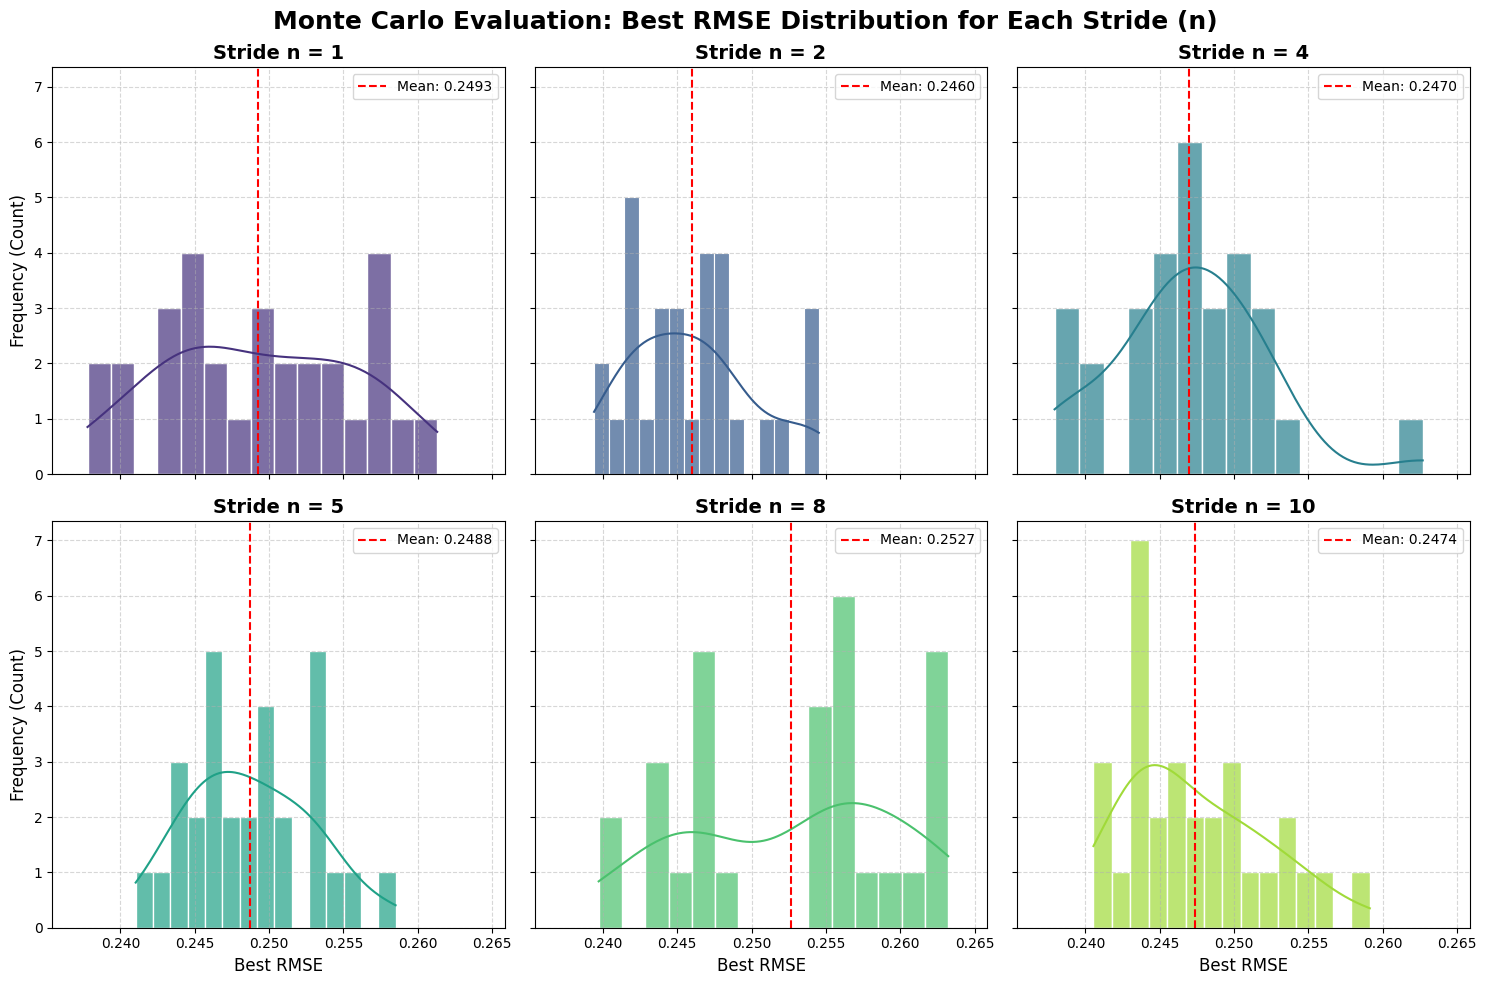

In [2]:
# =====================================================================
# データの読み込み ＆ 2行3列の垂直ヒストグラム整形プロット
# =====================================================================
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

csv_filename = "monte_carlo_results.csv"

if os.path.exists(csv_filename):
    df_res = pd.read_csv(csv_filename)
    df_res["Stride_n"] = df_res["Stride_n"].astype(int)
    df_res = df_res.sort_values("Stride_n")
else:
    print(f"エラー: {csv_filename} が見つかりません。")
    exit()

# 比較するストライド幅の順序
n_values = [1, 2, 4, 5, 8, 10]

# 2行3列のサブプロットを作成（横軸・縦軸のスケールを完全に統一）
fig, axes = plt.subplots(2, 3, figsize=(15, 10), sharex=True, sharey=True)
axes = axes.flatten()

# 全手法で横軸（RMSEの範囲）を揃えて比較しやすくする
xmin = df_res["Best_RMSE"].min() * 0.99
xmax = df_res["Best_RMSE"].max() * 1.01
palette = sns.color_palette("viridis", n_colors=len(n_values))

for i, n in enumerate(n_values):
    subset = df_res[df_res["Stride_n"] == n]
    ax = axes[i]
    
    # 垂直ヒストグラム + KDE曲線の描画
    sns.histplot(data=subset, x="Best_RMSE", kde=True, ax=ax, color=palette[i], 
                 bins=15, edgecolor="white", alpha=0.7, stat="count")
    
    # 試行の平均RMSEを計算して赤い破線を引く
    mean_val = subset["Best_RMSE"].mean()
    ax.axvline(mean_val, color="red", linestyle="--", linewidth=1.5, label=f"Mean: {mean_val:.4f}")
    
    # グラフの装飾
    ax.set_title(f"Stride n = {n}", fontsize=14, fontweight='bold')
    ax.set_xlabel("Best RMSE" if i >= 3 else "", fontsize=12)
    ax.set_ylabel("Frequency (Count)" if i % 3 == 0 else "", fontsize=12)
    ax.set_xlim(xmin, xmax)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc="upper right", fontsize=10)

plt.suptitle("Monte Carlo Evaluation: Best RMSE Distribution for Each Stride (n)", fontsize=18, y=0.98, fontweight='bold')
plt.tight_layout()

# 画像ファイルとして保存
plt.savefig("formatted_histograms.png", dpi=150)
plt.show()

In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# --- 1. データの読み込み ---
csv_filename = "monte_carlo_results.csv"
try:
    df = pd.read_csv(csv_filename)
except FileNotFoundError:
    print(f"エラー: '{csv_filename}' が見つかりません。データがあるディレクトリで実行してください。")
    exit()

print("=== 統計的有意差の検定を開始します ===")

# 各ストライド幅（n）のデータを抽出（ピボットテーブル化: 行=Seed, 列=Stride_n）
df_pivot = df.pivot(index="Seed", columns="Stride_n", values="Best_RMSE")
print(f"読み込み成功: 試行回数 {len(df_pivot)} シード、比較手法 {len(df_pivot.columns)} 種類\n")

# --- 2. ステップ1: フリードマン検定 (Friedman Test) ---
# 対応のある多群比較。データの正規性を仮定しない最も堅実な方法
groups_data = [df_pivot[col].values for col in df_pivot.columns]
stat, p_value = stats.friedmanchisquare(*groups_data)

print("【ステップ1: 全体としての検定 (Friedman Test)】")
print(f"検定統計量: {stat:.4f}")
print(f"p値 (p-value): {p_value:.4e}")

alpha = 0.05 # 有意水準 5%
if p_value < alpha:
    print(f"⇒ 結果: 有意差あり (p < {alpha})。ストライド幅によって統計的に明確な性能差が存在します。")
    print("   どのペアに差があるか、事後検定（多重比較）を行います。\n")
    
    # --- 3. ステップ2: 事後多重比較 (Post-hoc test) ---
    # ここでは、最も一般的に広く使われる「対応のあるt検定 + Holm補正」を行います
    print("【ステップ2: ペアごとの多重比較 (Pairwise Paired t-test with Holm correction)】")
    print(f"{'ペア (n vs n)':<15} | {'元のp値':<10} | {'補正後p値':<10} | {'有意差 (5%)'}")
    print("-" * 60)
    
    columns = df_pivot.columns
    p_pairs = []
    pair_labels = []
    
    # 全ペアの総当たり組み合わせで対応のあるt検定を実行
    for i in range(len(columns)):
        for j in range(i + 1, len(columns)):
            col1, col2 = columns[i], columns[j]
            # 対応のあるt検定 (Paired t-test)
            _, p_raw = stats.ttest_rel(df_pivot[col1], df_pivot[col2])
            p_pairs.append(p_raw)
            pair_labels.append((col1, col2))
            
    # Holmの方法で多重比較のp値を補正 (偽陽性を防ぐ)
    # statsmodelsのマルチプレックスを使用しても良いですが、マニュアルでHolmの判定を行います
    # scipyの多重比較用関数を使用
    from statsmodels.stats.multitest import multipletests
    reject, p_corrected, _, _ = multipletests(p_pairs, alpha=alpha, method='holm')
    
    # 結果の表示
    for (c1, c2), p_raw, p_corr, rej in zip(pair_labels, p_pairs, p_corrected, reject):
        status = "★ あり" if rej else "なし"
        print(f"n={c1:<2} vs n={c2:<2}    | {p_raw:.4f}   | {p_corr:.4f}   | {status}")

else:
    print(f"⇒ 結果: 有意差なし (p >= {alpha})。ノイズのランダムなばらつきの範囲内であり、統計的な性能差は認められません。")

=== 統計的有意差の検定を開始します ===
読み込み成功: 試行回数 30 シード、比較手法 6 種類

【ステップ1: 全体としての検定 (Friedman Test)】
検定統計量: 16.7810
p値 (p-value): 4.9345e-03
⇒ 結果: 有意差あり (p < 0.05)。ストライド幅によって統計的に明確な性能差が存在します。
   どのペアに差があるか、事後検定（多重比較）を行います。

【ステップ2: ペアごとの多重比較 (Pairwise Paired t-test with Holm correction)】
ペア (n vs n)     | 元のp値       | 補正後p値      | 有意差 (5%)
------------------------------------------------------------
n=1  vs n=2     | 0.0137   | 0.1262   | なし
n=1  vs n=4     | 0.0209   | 0.1671   | なし
n=1  vs n=5     | 0.6448   | 1.0000   | なし
n=1  vs n=8     | 0.0097   | 0.1062   | なし
n=1  vs n=10    | 0.0908   | 0.5451   | なし
n=2  vs n=4     | 0.3227   | 0.9682   | なし
n=2  vs n=5     | 0.0126   | 0.1262   | なし
n=2  vs n=8     | 0.0001   | 0.0008   | ★ あり
n=2  vs n=10    | 0.1096   | 0.5480   | なし
n=4  vs n=5     | 0.0677   | 0.4737   | なし
n=4  vs n=8     | 0.0000   | 0.0004   | ★ あり
n=4  vs n=10    | 0.6722   | 1.0000   | なし
n=5  vs n=8     | 0.0017   | 0.0205   | ★ あり
n=5  vs n=10    | 0.2221   | 0.8884   | なし
n

In [3]:
# =====================================================================
# モンテカルロ評価: 観測ノイズ中心化・CSV自動保存・2行3列垂直ヒストグラム版
# =====================================================================
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import time
import concurrent.futures
from tqdm import tqdm

# --- 1. グローバルパラメータ設定 (ユーザーの環境と完全一致) ---
N = 40                  # 変数の数
F = 8.0                 # 強制項
dt = 0.01               # 積分時間ステップ
sampling_dt = 0.05      # 観測・同化の間隔
m = 8                   # アンサンブルメンバー数

years = 2
units_per_year = 73.0   
total_time = years * units_per_year
spin_up_time = units_per_year

steps_total = int(total_time / dt)
steps_spin_up = int(spin_up_time / dt)
sampling_interval = int(sampling_dt / dt)

H_mat = np.eye(N)       # 観測演算子 H (全点観測)
R_mat = np.eye(N)       # 観測誤差共分散 R (対角成分1)

# --- 2. モデルと局所化関数の定義 ---
def lorenz96(x, F):
    return (np.roll(x, -1, axis=0) - np.roll(x, 2, axis=0)) * np.roll(x, 1, axis=0) - x + F

def M(x_in, dt, steps):
    x_out = x_in.copy()
    for _ in range(steps):
        k1 = lorenz96(x_out, F)
        k2 = lorenz96(x_out + k1 * (dt / 2.0), F)
        k3 = lorenz96(x_out + k2 * (dt / 2.0), F)
        k4 = lorenz96(x_out + k3 * dt, F)
        x_out += (k1 + 2.0*k2 + 2.0*k3 + k4) * (dt / 6.0)
    return x_out

def Gaspari_Cohn_L(sigma):
    L = np.zeros((N, N))
    for i in range(N):
        for j in range(N):
            d = min(abs(i - j), N - abs(i - j))
            r = d / (np.sqrt(10 / 3) * sigma)
            if r <= 1.0:
                val = 1 - 1/4 * r**5 + 1/2 * r**4 + 5/8 * r**3 - 5/3 * r**2
            elif r <= 2.0:
                val = 1/12 * r**5 - 1/2 * r**4 + 5/8 * r**3 + 5/3 * r**2 - 5 * r + 4 - 2/3 * (1/r)
            else:
                val = 0.0
            L[i, j] = val
    return L

# --- 3. 同化アルゴリズム定義 (ユーザーロジック高速汎用版) ---
def run_EnSRF_Generic_fast(y_o_data, true_states_input, delta, sigma, assimilation_order):
    num_cycles = y_o_data.shape[0]
    L_matrix = Gaspari_Cohn_L(sigma)
    
    rng = np.random.default_rng(seed=42) 
    x_raw_init = np.full(N, F)
    x_raw_init[min(19, N-1)] += 0.001
    X_a = M(x_raw_init[:, None] + rng.normal(0, 0.1, (N, m)), dt, steps_spin_up)

    rmse_record = np.zeros(num_cycles)

    for t in range(num_cycles):
        X_b = M(X_a, dt, sampling_interval)
        
        x_b_mean_inf = np.mean(X_b, axis=1, keepdims=True)
        X_b = X_b + delta * (X_b - x_b_mean_inf)
        
        x_mean = np.mean(X_b, axis=1, keepdims=True)
        Z_background = X_b - x_mean
        
        for i in assimilation_order:
            y_o_i = y_o_data[t, i]
            H_i = H_mat[i:i+1, :]
            R_i = R_mat[i, i]
            
            Y_background = H_i @ Z_background
            L_loc = L_matrix[:, i:i+1]
            
            Pb_HT = L_loc * (Z_background @ Y_background.T) / (m - 1)
            H_Pb_HT = (Y_background @ Y_background.T) / (m - 1)
            
            K = Pb_HT / (H_Pb_HT + R_i)
            hpbht = H_Pb_HT.item() if isinstance(H_Pb_HT, np.ndarray) else H_Pb_HT
            K_tilde = K * (1.0 / (1.0 + np.sqrt(R_i / (hpbht + R_i))))
            
            x_mean = x_mean + K * (y_o_i - H_i @ x_mean)
            Z_background = Z_background - K_tilde @ Y_background
            
        X_a = Z_background + x_mean
        rmse_record[t] = np.sqrt(np.mean((np.squeeze(x_mean) - true_states_input[t])**2))
        
    return np.mean(rmse_record[50:])

# --- 4. 各シードごとの評価タスク (ノイズ中心化を適用) ---
def evaluate_seed_stride(seed, n, delta_range, sigma_range, true_states_input):
    rng_obs = np.random.default_rng(seed=seed)
    noise = rng_obs.normal(loc=0.0, scale=1.0, size=true_states_input.shape)
    
    # 【整合性確保のキモ】各変数ごとに平均0に強制調整（中心化）
    noise -= np.mean(noise, axis=0)  
    y_o_data = true_states_input + noise
    
    order_n = [i for rem in range(n) for i in range(N) if i % n == rem]
    
    best_rmse = float('inf')
    best_delta, best_sigma = None, None
    
    for d in delta_range:
        for s in sigma_range:
            rmse = run_EnSRF_Generic_fast(y_o_data, true_states_input, d, s, order_n)
            if np.isnan(rmse) or np.isinf(rmse):
                rmse = 1.0 
            if rmse < best_rmse:
                best_rmse = rmse
                best_delta = d
                best_sigma = s
                
    return seed, n, best_delta, best_sigma, best_rmse

# --- 5. メイン実行ブロック ---
if __name__ == "__main__":
    csv_filename = "monte_carlo_results_centered.csv"
    
    # CSVが存在すれば自動読み込み（再計算を完全スキップ）
    if os.path.exists(csv_filename):
        print(f"既存のデータ '{csv_filename}' を読み込みます...")
        df_res = pd.read_csv(csv_filename)
        df_res["Stride_n"] = df_res["Stride_n"].astype(int)
        
    else:
        print("データが見つかりません。シミュレーションを実行します...")
        print("Nature Run (真値) を生成中...")
        x_init = np.full(N, F)
        x_init[19] += 0.001
        true_states = []
        for s in range(steps_total):
            x_init = M(x_init, dt, 1)
            if s >= steps_spin_up and (s - steps_spin_up) % sampling_interval == 0:
                true_states.append(x_init.copy())
        true_states = np.array(true_states)
        print(f"真値生成完了！ (同化サイクル数: {len(true_states)})\n")

        num_seeds = 30
        seed_list = list(range(1000, 1000 + num_seeds))
        n_values = [1, 2, 4, 5, 8, 10]
        
        # パラメータ探索範囲
        delta_range = np.linspace(0.0, 0.5, 6)
        sigma_range = np.linspace(1.0, 6.0, 6)
        tasks = [(seed, n) for seed in seed_list for n in n_values]

        print(f"合計 {len(tasks) * 36} 回の同化計算をマルチプロセスで開始します...")
        start_time = time.time()
        results = []

        # concurrent.futures で確実に進捗を1%ずつ更新
        with concurrent.futures.ProcessPoolExecutor() as executor:
            futures = [executor.submit(evaluate_seed_stride, seed, n, delta_range, sigma_range, true_states) for seed, n in tasks]
            for future in tqdm(concurrent.futures.as_completed(futures), total=len(tasks), desc="モンテカルロ探索"):
                results.append(future.result())

        print(f"探索完了！ 実行時間: {time.time() - start_time:.2f} 秒\n")
        
        df_res = pd.DataFrame(results, columns=["Seed", "Stride_n", "Best_Delta", "Best_Sigma", "Best_RMSE"])
        df_res["Stride_n"] = df_res["Stride_n"].astype(int)
        
        # CSVへ書き出し
        df_res.to_csv(csv_filename, index=False)
        print(f"結果を '{csv_filename}' に自動保存しました！")

    # --- 6. データの整形と可視化 (2行3列・垂直ヒストグラム) ---
    df_res = df_res.sort_values("Stride_n")
    n_values = [1, 2, 4, 5, 8, 10]
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10), sharex=True, sharey=True)
    axes = axes.flatten()

    # 横軸スケールの統一
    xmin = df_res["Best_RMSE"].min() * 0.99
    xmax = df_res["Best_RMSE"].max() * 1.01
    palette = sns.color_palette("viridis", n_colors=len(n_values))

    for i, n in enumerate(n_values):
        subset = df_res[df_res["Stride_n"] == n]
        ax = axes[i]
        
        # 垂直ヒストグラム
        sns.histplot(data=subset, x="Best_RMSE", kde=True, ax=ax, color=palette[i], 
                     bins=15, edgecolor="white", alpha=0.7, stat="count")
        
        mean_val = subset["Best_RMSE"].mean()
        ax.axvline(mean_val, color="red", linestyle="--", linewidth=1.5, label=f"Mean: {mean_val:.4f}")
        
        ax.set_title(f"Stride n = {n}", fontsize=14, fontweight='bold')
        ax.set_xlabel("Best RMSE" if i >= 3 else "", fontsize=12)
        ax.set_ylabel("Frequency (Count)" if i % 3 == 0 else "", fontsize=12)
        ax.set_xlim(xmin, xmax)
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend(loc="upper right", fontsize=10)

    plt.suptitle("Monte Carlo Evaluation: Best RMSE Distribution (With Centered Noise)", fontsize=18, y=0.98, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # 簡易統計情報の出力
    print("\n【各手法の平均RMSE（30シード）】")
    summary = df_res.groupby("Stride_n")["Best_RMSE"].mean().reset_index()
    print(summary.to_string(index=False))

データが見つかりません。シミュレーションを実行します...
Nature Run (真値) を生成中...
真値生成完了！ (同化サイクル数: 1460)

合計 6480 回の同化計算をマルチプロセスで開始します...


モンテカルロ探索:   0%|          | 0/180 [00:00<?, ?it/s]


BrokenProcessPool: A process in the process pool was terminated abruptly while the future was running or pending.